# Boxplots

In [1]:
import os
os.environ["R_HOME"] = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/R"

qiime_env = "/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1"
os.environ["PATH"] = f"{qiime_env}/bin:/usr/local/bin:/usr/bin:/bin"
os.environ["CONDA_PREFIX"] = qiime_env


In [2]:
import ancombc2_heatmaps
print(ancombc2_heatmaps.__file__)

/homes/kbalzer/miniconda3/envs/qiime2-amplicon-2026.1/lib/python3.10/site-packages/ancombc2_heatmaps/__init__.py


In [3]:
from ancombc2_heatmaps import (
    PlotWorkflow,
    HeatmapConfig,
    MetadataConfig,
    ComparisonConfig,
    PathConfig,
    SubsetSpec,
    TrajectoryConfig,
    TrajectoryMetadataConfig,
    TrajectoryPathConfig,
    TrajectoryPlotConfig,
)

print("Imports ok")

Imports ok


In [4]:
META_FP = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/metadata_microbian2_26.02.2026.txt"

TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups"

ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_partial_groups/ancombc2_treatment"

OUTDIR = "/tmp/ancombc2_notebook_test"

print("Paths ok")

Paths ok


In [5]:
TIMEPOINTS = [
    "baseline1", "baseline2", "baseline3",
    "day1", "day3", "day7", "day14"
]

TIMEPOINT_MAP = {
    "baseline_1": "baseline1",
    "baseline_2": "baseline2",
    "baseline_3": "baseline3",
    "day_1_post": "day1",
    "day_3_post": "day3",
    "day_7_post": "day7",
    "day_14_post": "day14",
    "baseline1": "baseline1",
    "baseline2": "baseline2",
    "baseline3": "baseline3",
    "day1": "day1",
    "day3": "day3",
    "day7": "day7",
    "day14": "day14",
}

TIMEPOINT_NUMERIC_MAP = {
    "baseline_1": -7,
    "baseline_2": -4,
    "baseline_3": -1,
    "day_1_post": 1,
    "day_3_post": 3,
    "day_7_post": 7,
    "day_14_post": 14,
    "baseline1": -7,
    "baseline2": -4,
    "baseline3": -1,
    "day1": 1,
    "day3": 3,
    "day7": 7,
    "day14": 14,
}

TP_LABEL_MAP = {
    0: "baseline",
    -7: "baseline1",
    -4: "baseline2",
    -1: "baseline3",
    1: "day1",
    3: "day3",
    7: "day7",
    14: "day14",
}

print("Timepoints ok")

Timepoints ok


In [6]:
heatmap_config = HeatmapConfig(
    metadata=MetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        comparison_col="description_of_treatment",
        timepoints=TIMEPOINTS,
        timepoint_map=TIMEPOINT_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["male", "female"],
        },
    ),
    comparison=ComparisonConfig(
        variable_name="description_of_treatment",
        positive_class="irradiated",
        negative_class="sham",
    ),
    paths=PathConfig(
        base_table_dir=TABLE_BASE,
        base_ancom_dir=ANCOM_BASE,
        metadata_path=META_FP,
        output_dir=OUTDIR,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_treat_ANCOMB_exported",
    ),
    cell_text_mode="relative_abundance",
    split_after_timepoint="baseline3",
    min_sig_cells_per_taxon=1,
)

print("Heatmap config ok")

Heatmap config ok


In [7]:
traj_config = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="description_of_treatment",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_treat_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=True,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={
            "sham": "",
            "irradiated": (4, 2),
        },
        figsize=(12, 8),
    ),
)

print("Trajectory config ok")

Trajectory config ok


In [8]:
workflow = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config,
)

print("Workflow ok")

subset = SubsetSpec(
    label="WT_genus_ANCOM",
    title="WT | sham vs irradiated",
    filters={
        "mice_model": "WT",
    },
)

print("Subset ok")

Workflow ok
Subset ok


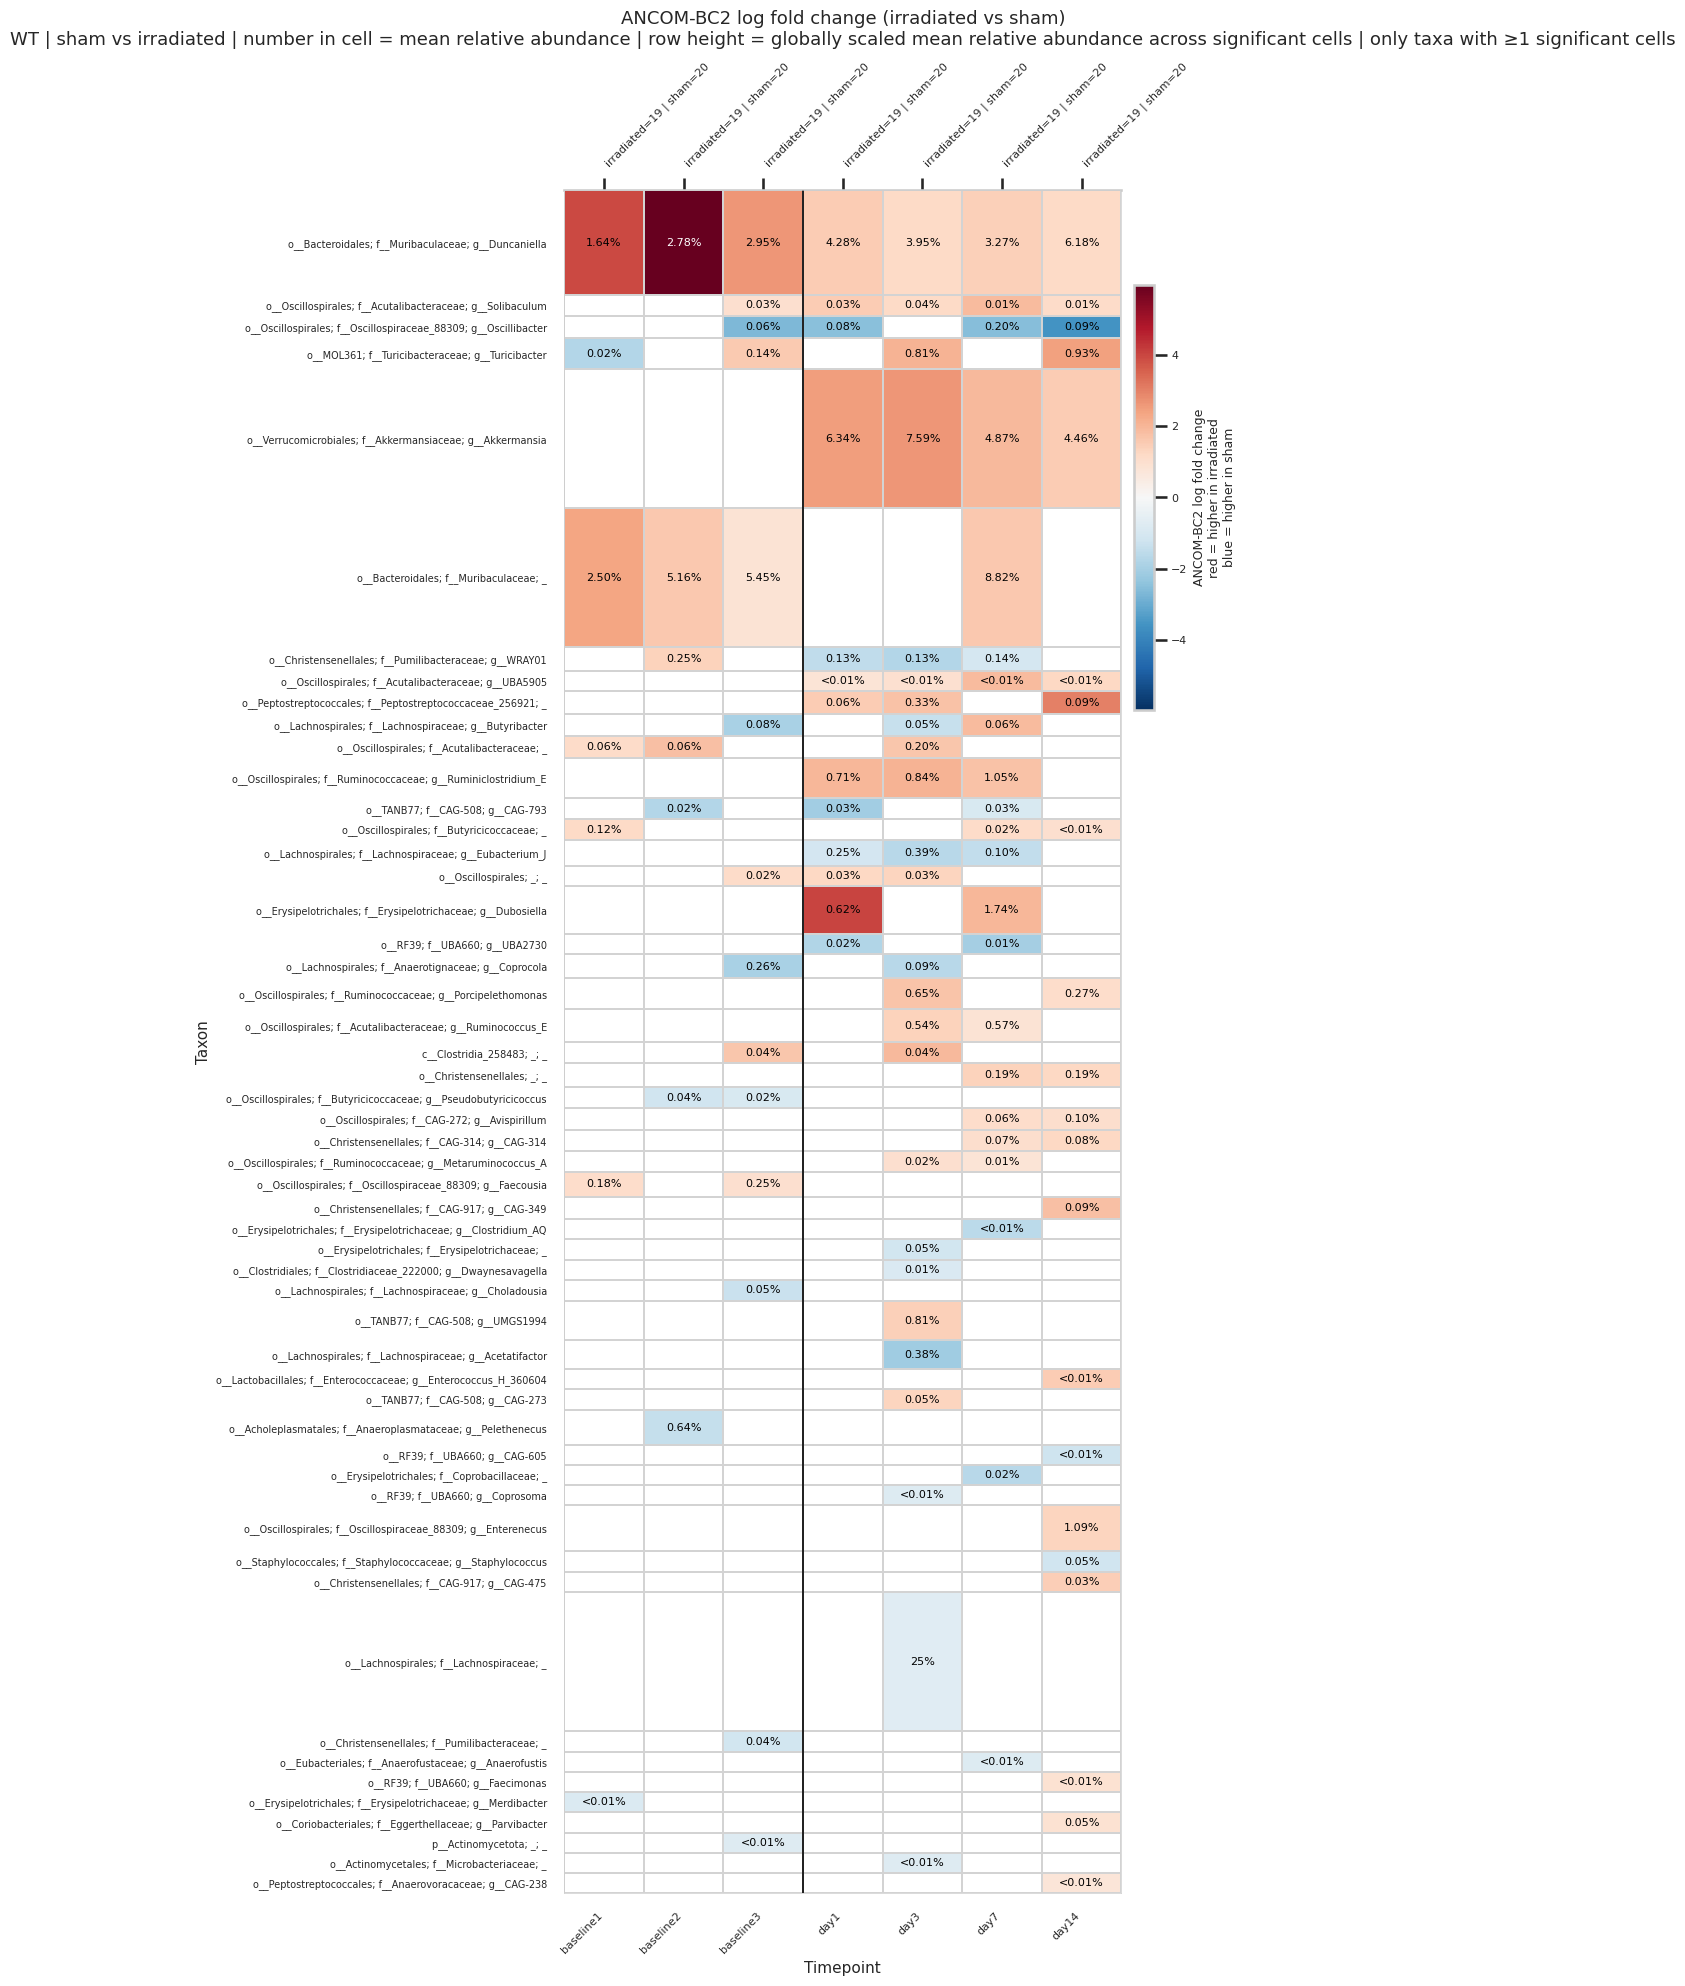

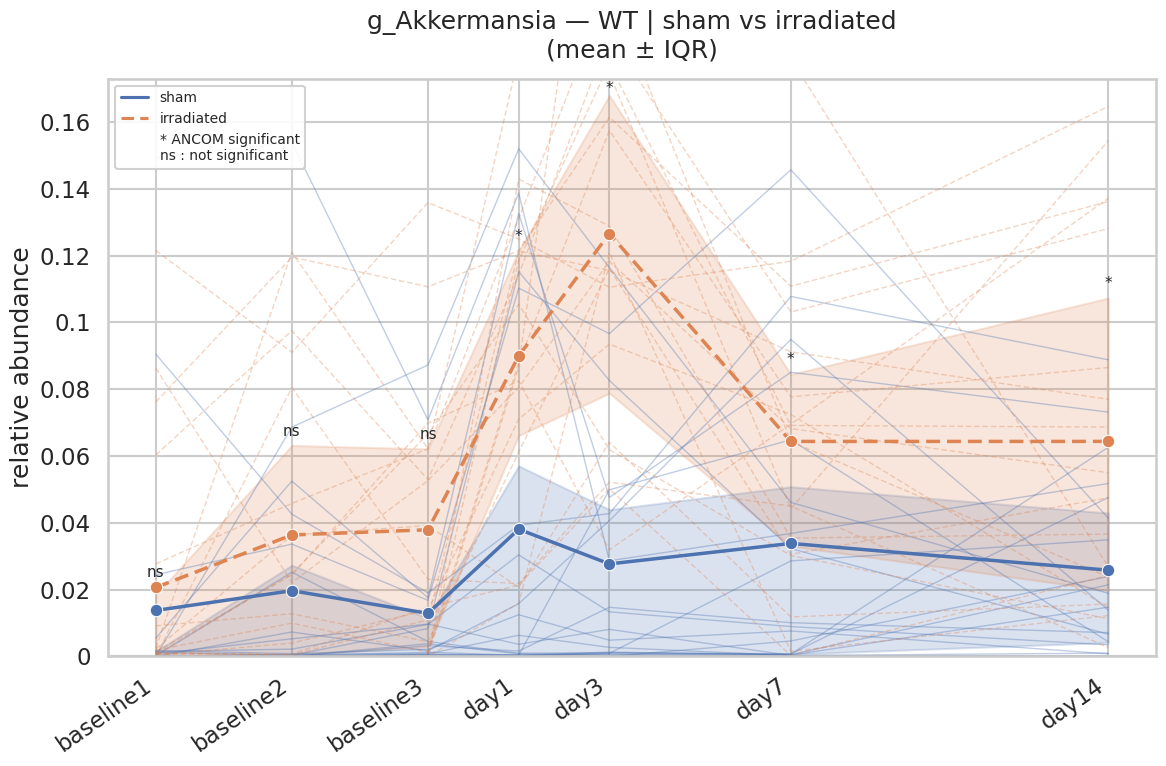

In [9]:
workflow.plot_heatmap_and_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
    heatmap_kwargs={
        "show": True,
        "save_png": False,
        "save_pdf": False,
    },
)

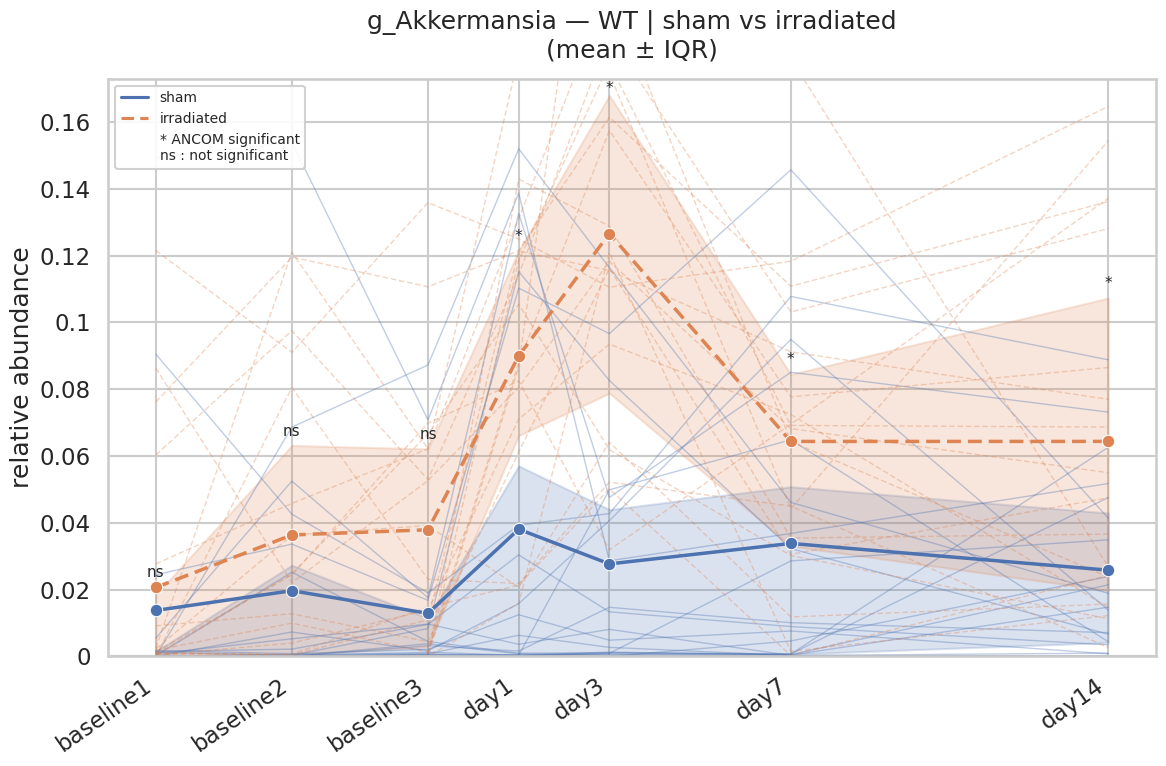

In [10]:
workflow.plot_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
)

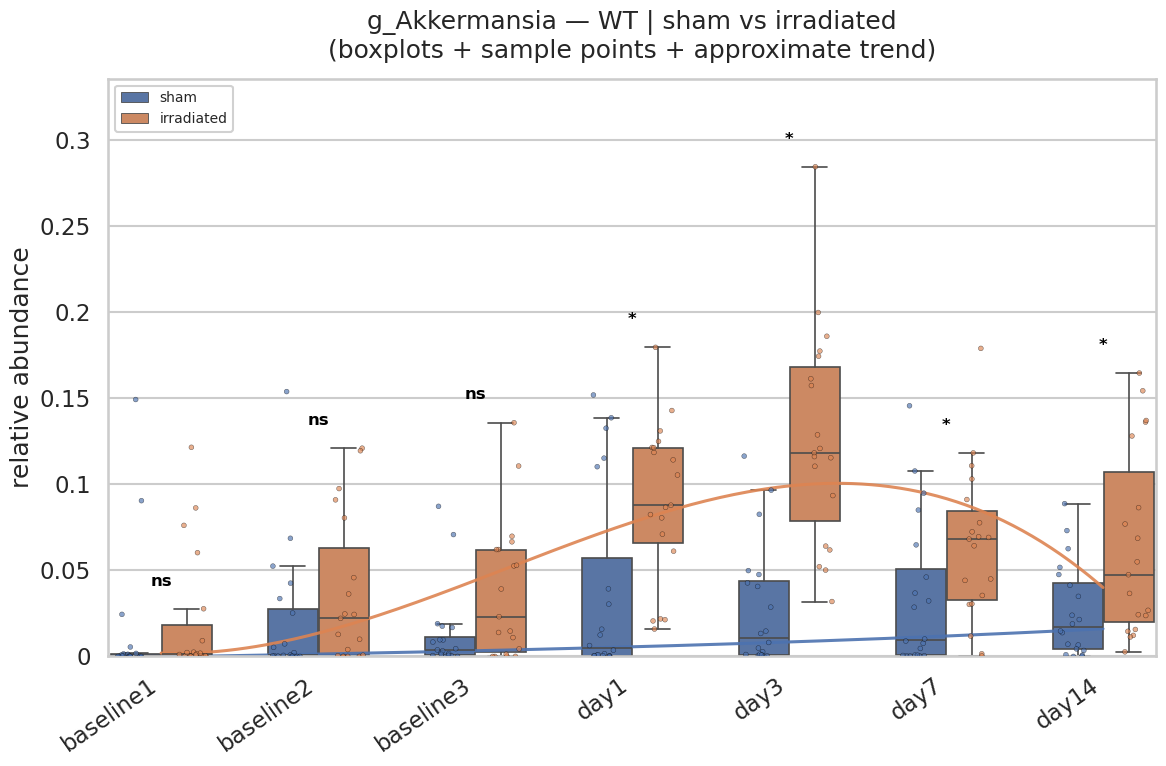

In [11]:
workflow.plot_boxplot_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
    show_trend=True,
    trend_order=3,
)

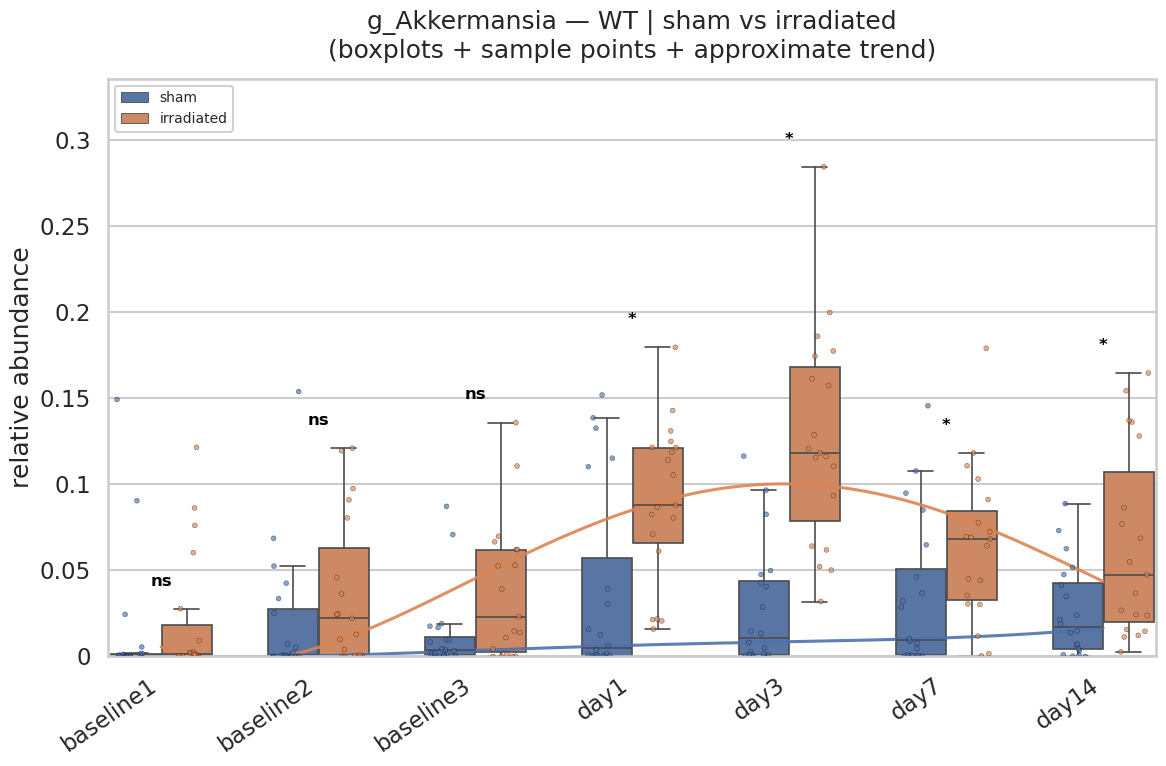

In [12]:
subset = SubsetSpec(
    label="WT_genus_ANCOM",
    title="WT | sham vs irradiated",
    filters={"mice_model": "WT"},
)

workflow.plot_boxplot_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
    show_trend=True,
    trend_order=4,
)

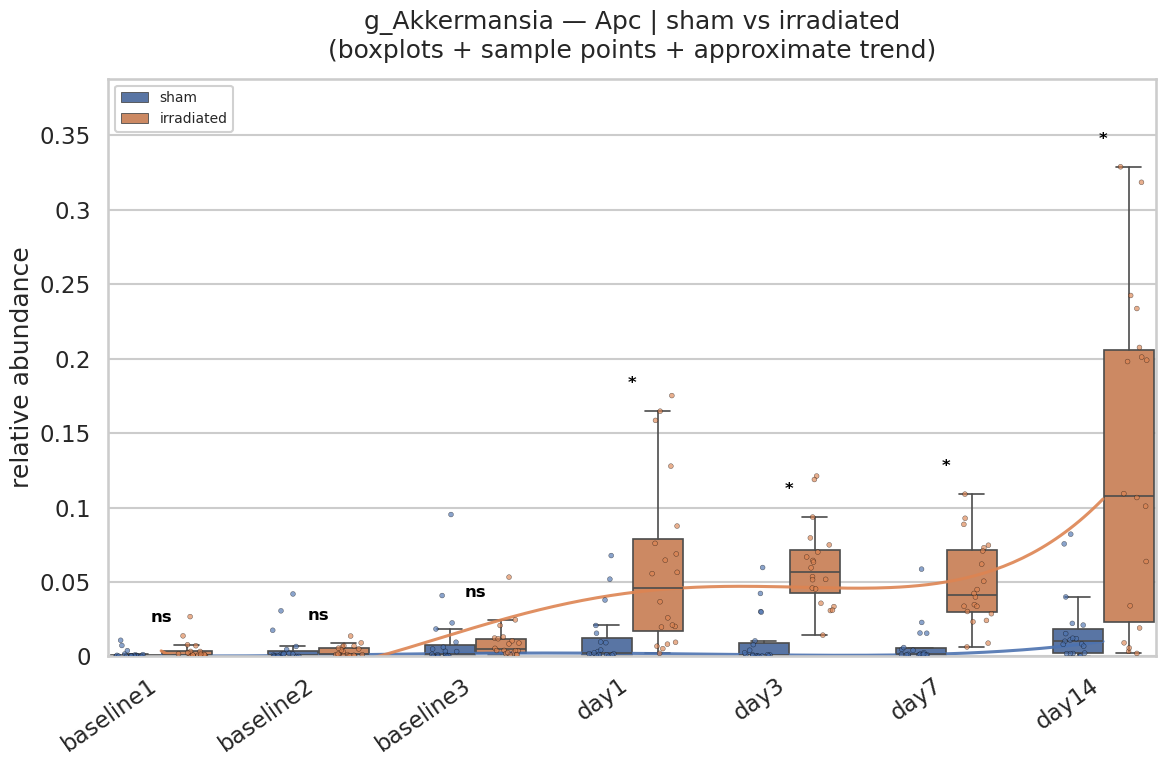

In [13]:
subset = SubsetSpec(
    label="Apc_genus_ANCOM",
    title="Apc | sham vs irradiated",
    filters={"mice_model": "Apc"},
)

workflow.plot_boxplot_trajectory(
    subset=subset,
    taxon_query="g_Akkermansia",
    comparison_levels=["sham", "irradiated"],
    show_trend=True,
    trend_order=4,
)

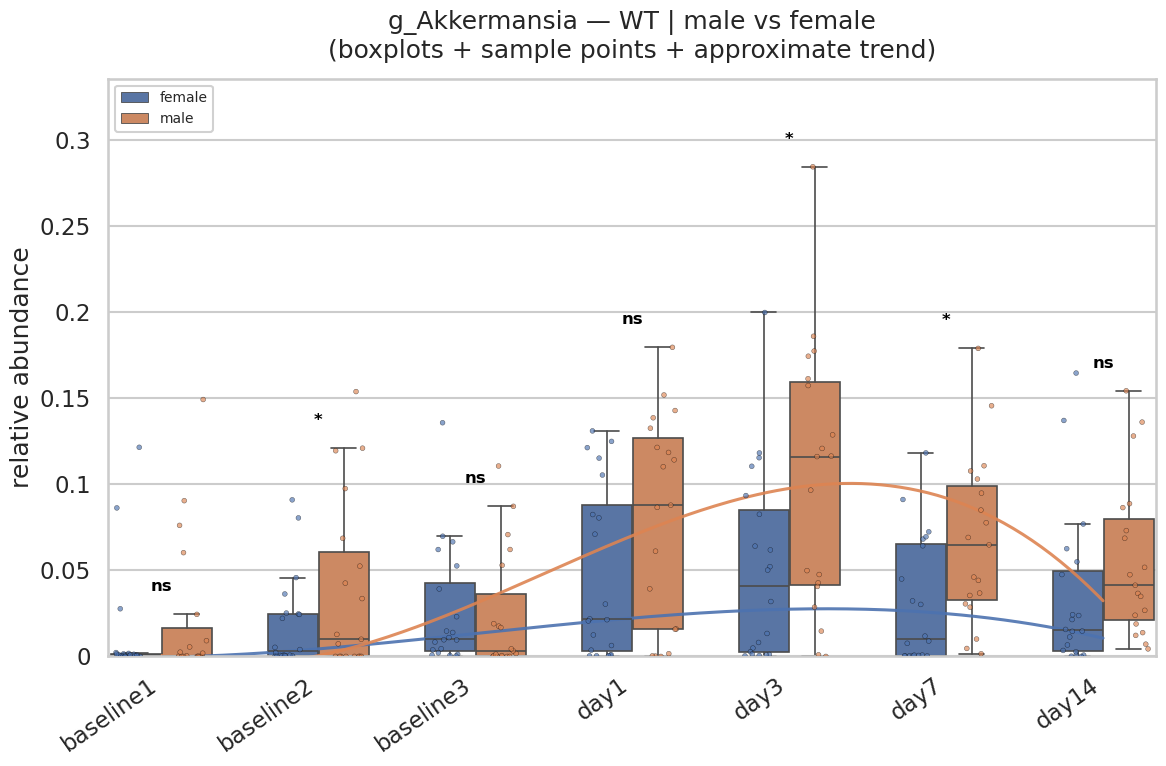

In [15]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex"

traj_config_sex = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_sex = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_sex,
)

subset_sex = SubsetSpec(
    label="WT_alltreat_genus_ANCOM",
    title="WT | male vs female",
    filters={"mice_model": "WT"},
)

workflow_sex.plot_boxplot_trajectory(
    subset=subset_sex,
    taxon_query="g_Akkermansia",
    comparison_levels=["female", "male"],
    show_trend=True,
    trend_order=3,
)

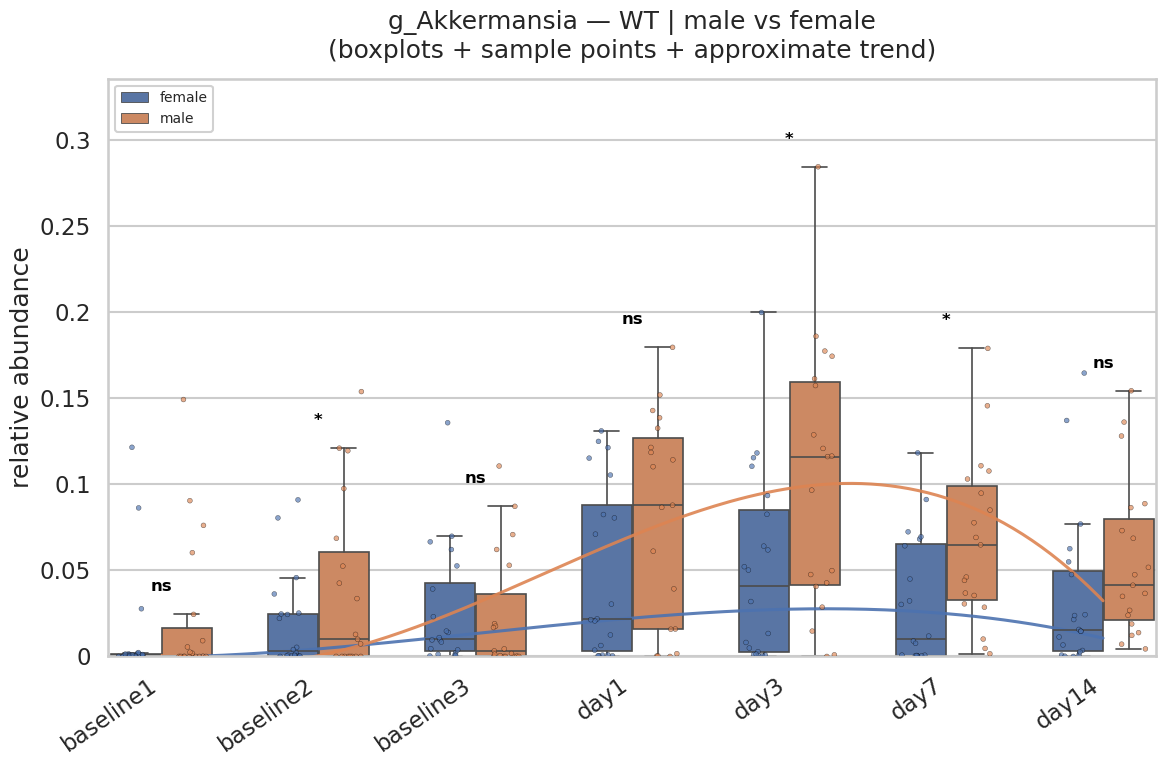

In [16]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex"

traj_config_sex = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_sex = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_sex,
)

subset_sex = SubsetSpec(
    label="WT_alltreat_genus_ANCOM",
    title="WT | male vs female",
    filters={"mice_model": "WT"},
)

workflow_sex.plot_boxplot_trajectory(
    subset=subset_sex,
    taxon_query="g_Akkermansia",
    comparison_levels=["female", "male"],
    show_trend=True,
    trend_order=3,
)

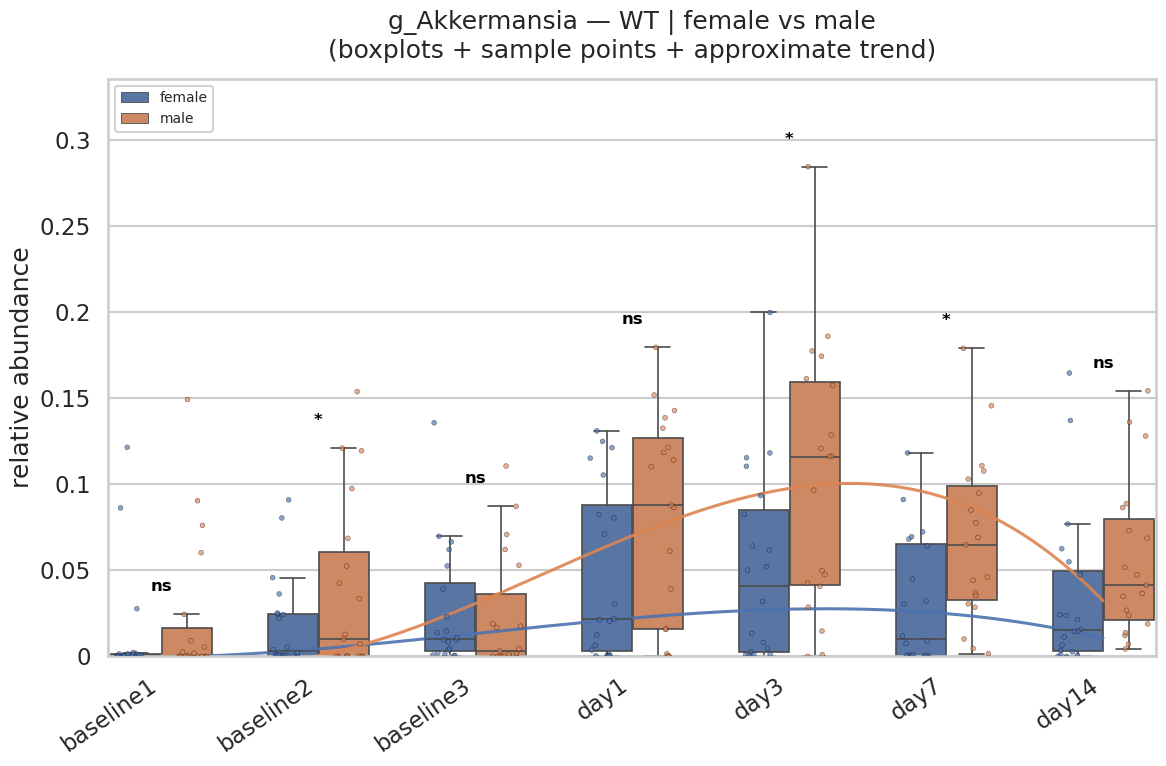

In [17]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex"

traj_config_sex_WT = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_sex_WT = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_sex_WT,
)

subset_sex_WT = SubsetSpec(
    label="WT_alltreat_genus_ANCOM",
    title="WT | female vs male",
    filters={"mice_model": "WT"},
)

workflow_sex_WT.plot_boxplot_trajectory(
    subset=subset_sex_WT,
    taxon_query="g_Akkermansia",
    comparison_levels=["female", "male"],
    show_trend=True,
    trend_order=3,
)

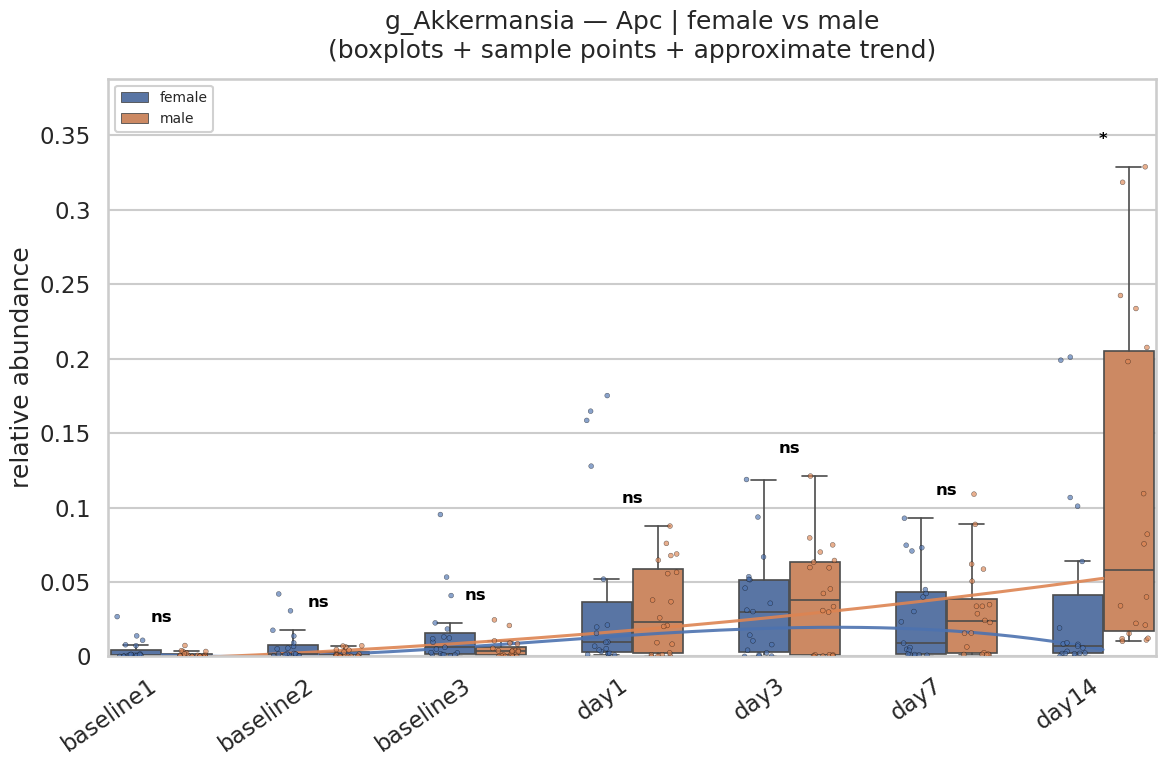

In [18]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_sex/ancombc2_sex"

traj_config_sex_Apc = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="sex",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female", "male"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_sex_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_sex_Apc = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_sex_Apc,
)

subset_sex_Apc = SubsetSpec(
    label="Apc_alltreat_genus_ANCOM",
    title="Apc | female vs male",
    filters={"mice_model": "Apc"},
)

workflow_sex_Apc.plot_boxplot_trajectory(
    subset=subset_sex_Apc,
    taxon_query="g_Akkermansia",
    comparison_levels=["female", "male"],
    show_trend=True,
    trend_order=3,
)

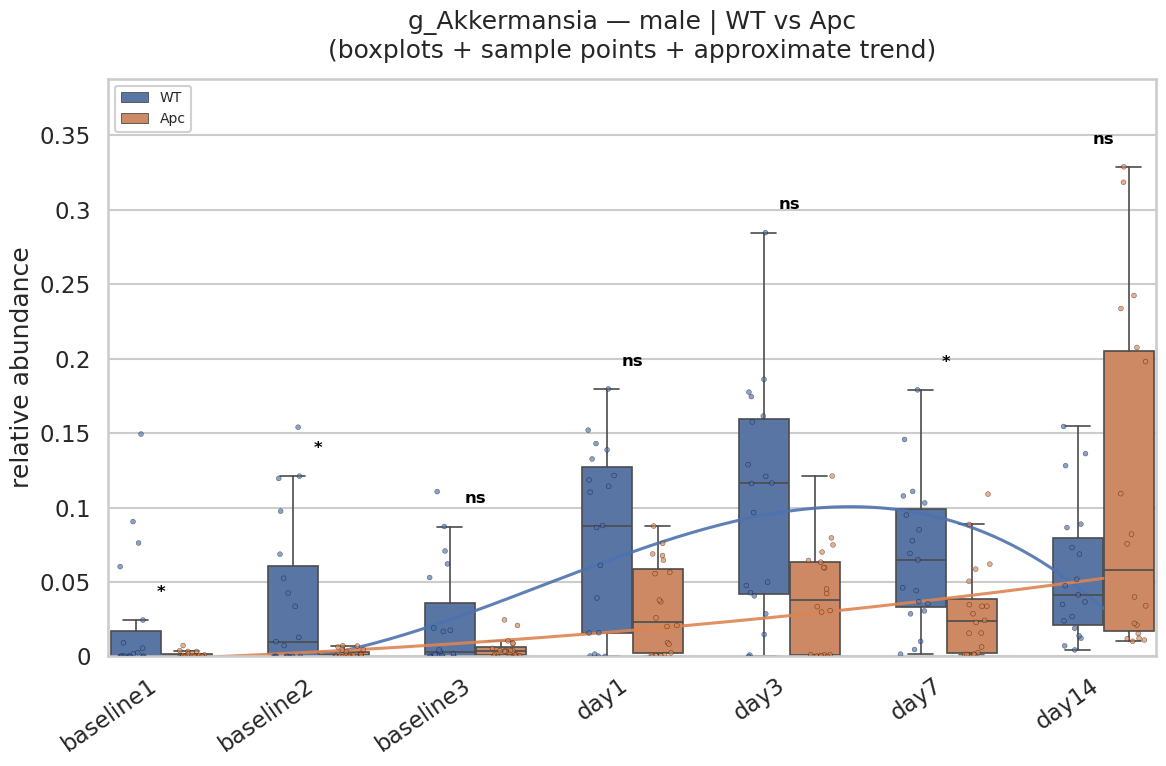

In [19]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype/ancombc2_genotype"

traj_config_genotype_male = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="mice_model",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["male"],
            "mice_model": ["WT", "Apc"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_genotype_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_genotype_male = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_genotype_male,
)

subset_genotype_male = SubsetSpec(
    label="male_alltreat_genus_ANCOM",
    title="male | WT vs Apc",
    filters={"sex": "male"},
)

workflow_genotype_male.plot_boxplot_trajectory(
    subset=subset_genotype_male,
    taxon_query="g_Akkermansia",
    comparison_levels=["WT", "Apc"],
    show_trend=True,
    trend_order=3,
)

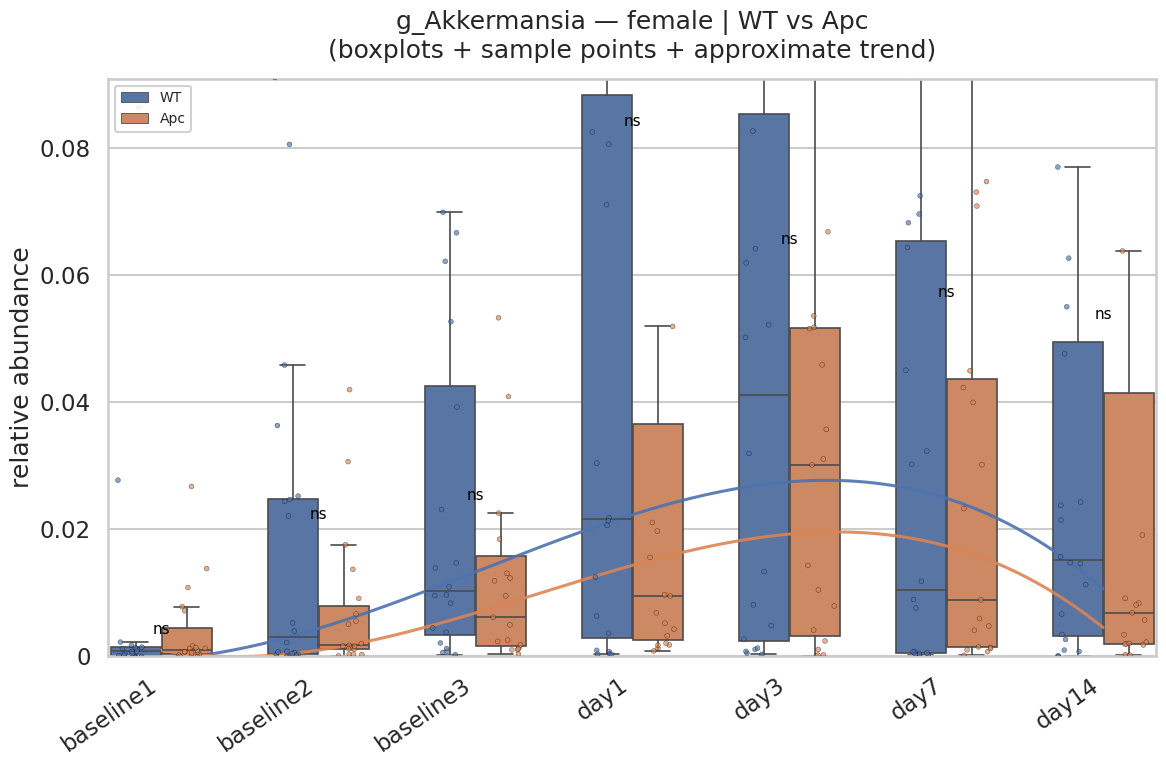

In [21]:
TABLE_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype"
ANCOM_BASE = "/vol/jlab/MicrobiomeAnalyses/Projects/JansenVanVuuren_Microbian2/Karl/heatmaps_genus_by_timepoint/by_genotype/ancombc2_genotype"

traj_config_genotype_female = TrajectoryConfig(
    metadata=TrajectoryMetadataConfig(
        sample_col="sample_name",
        timepoint_col="time_point",
        mouse_col="host_subject_id",
        comparison_col="mice_model",
        genotype_col="mice_model",
        treatment_col="description_of_treatment",
        timepoint_order=TIMEPOINTS,
        timepoint_numeric_map=TIMEPOINT_NUMERIC_MAP,
        timepoint_label_map=TP_LABEL_MAP,
        allowed_values={
            "description_of_treatment": ["sham", "irradiated"],
            "sex": ["female"],
            "mice_model": ["WT", "Apc"],
        },
    ),
    paths=TrajectoryPathConfig(
        metadata_path=META_FP,
        table_base=TABLE_BASE,
        ancom_base=ANCOM_BASE,
        table_template="{timepoint}/table_{timepoint}_{subset_label}.qza",
        ancom_template="{timepoint}/table_{timepoint}_{subset_label}_genotype_ANCOMB_exported",
    ),
    plot=TrajectoryPlotConfig(
        estimator="mean",
        error_style="iqr",
        show_individual_lines=False,
        merge_baselines=False,
        y_lim="auto_fix",
        show_significance=True,
        line_styles={},
        figsize=(12, 8),
    ),
)

workflow_genotype_female = PlotWorkflow(
    heatmap_config=heatmap_config,
    trajectory_config=traj_config_genotype_female,
)

subset_genotype_female = SubsetSpec(
    label="female_alltreat_genus_ANCOM",
    title="female | WT vs Apc",
    filters={"sex": "female"},
)

workflow_genotype_female.plot_boxplot_trajectory(
    subset=subset_genotype_female,
    taxon_query="g_Akkermansia",
    comparison_levels=["WT", "Apc"],
    show_trend=True,
    trend_order=3,
)

In [31]:
print("test")

test
